# Лабораторна робота №5. Алгоритми пошуку
##### AUTHOR
© Куценко Данило

### Мета
Засвоїти принципи роботи базових алгоритмів пошуку (лінійного та бінарного), реалізувати їх мовою Python та порівняти їхню асимптотичну складність на практиці.

## Хід роботи
### Завдання
Реалізувати алгоритми лінійного та бінарного пошуку. Провести експериментальне дослідження часу виконання обох алгоритмів на відсортованих масивах різного розміру та побудувати графік залежності часу від розміру масиву $n$.

### Виконання
Лінійний пошук перевіряє кожен елемент масиву послідовно і має складність $O(n)$. Бінарний пошук працює за принципом «розділяй і володарюй», ділячи відсортований масив навпіл, що забезпечує логарифмічну складність $O(\log n)$.

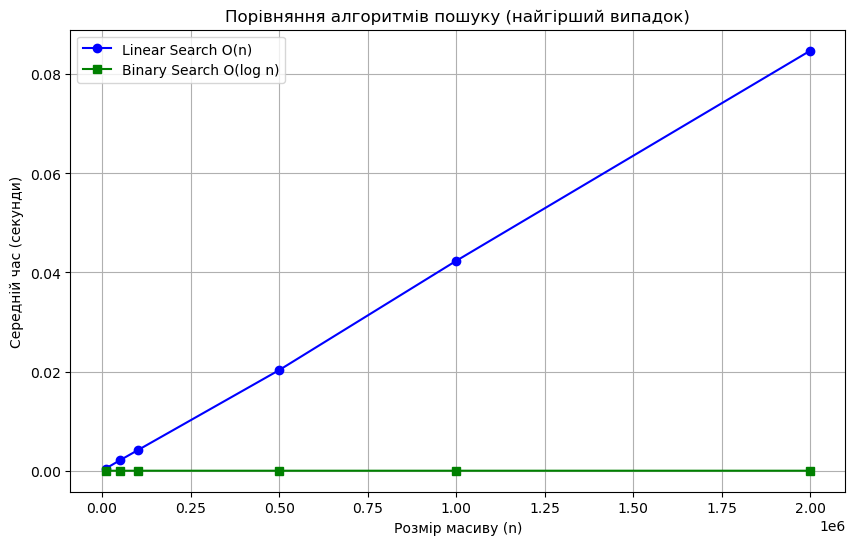

In [6]:
import random
import time
import matplotlib.pyplot as plt

# 1. Лінійний пошук
def linear_search(arr, target):
    for i in range(len(arr)):
        if arr[i] == target:
            return i
    return -1

# 2. Бінарний пошук
def binary_search(arr, target):
    left, right = 0, len(arr) - 1
    while left <= right:
        mid = (left + right) // 2
        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            left = mid + 1
        else:
            right = mid - 1
    return -1

# 3. Тестування алгоритмів
sizes = [10000, 50000, 100000, 500000, 1000000, 2000000]
times_linear = []
times_binary = []

for n in sizes:
    # Генеруємо відсортований масив (бінарний пошук вимагає відсортованих даних)
    arr = list(range(n))
    target = n - 1  # Шукаємо останній елемент (найгірший випадок)
    
    # Замір часу для лінійного пошуку (робимо 100 повторень для точності)
    start = time.time()
    for _ in range(100):
        linear_search(arr, target)
    times_linear.append((time.time() - start) / 100)
    
    # Замір часу для бінарного пошуку
    start = time.time()
    for _ in range(100):
        binary_search(arr, target)
    times_binary.append((time.time() - start) / 100)

# 4. Побудова графіка
plt.figure(figsize=(10, 6))
plt.plot(sizes, times_linear, label="Linear Search O(n)", marker='o', color='blue')
plt.plot(sizes, times_binary, label="Binary Search O(log n)", marker='s', color='green')
plt.xlabel("Розмір масиву (n)")
plt.ylabel("Середній час (секунди)")
plt.title("Порівняння алгоритмів пошуку (найгірший випадок)")
plt.legend()
plt.grid(True)
plt.show()

## Висновок
Під час виконання роботи я реалізував два базові алгоритми пошуку. Експериментальні дані повністю підтверджують теоретичну асимптотичну складність: час виконання лінійного пошуку зростає лінійно $O(n)$ зі збільшенням масиву, тоді як час бінарного пошуку залишається майже незмінним і близьким до нуля завдяки логарифмічній складності $O(\log n)$. 

## Контрольні питання

### 1. Яка головна вимога для застосування бінарного пошуку?
Бінарний пошук можна застосовувати виключно до попередньо відсортованих масивів (чи списків).

### 2. Яка асимптотична складність лінійного пошуку в найкращому, середньому та найгіршому випадках?
- Найкращий: $O(1)$ (елемент на першій позиції).
- Середній: $O(n/2) \approx O(n)$ (елемент десь посередині).
- Найгірший: $O(n)$ (елемент відсутній або знаходиться в самому кінці).

### 3. Чи завжди бінарний пошук кращий за лінійний?
Ні. Якщо масив дуже малий, витрати на логіку бінарного пошуку можуть перевищувати час звичайного перебору. Також, якщо масив не відсортований, витрати часу на його попереднє сортування $O(n \log n)$ зроблять пошук одного елемента неефективним порівняно з єдиним лінійним проходом $O(n)$.